## Extract database

In [97]:
#import kagglehub

# Download if the dataset is not already downloaded & if exists in the cache, it will return the path to the dataset files
#path = kagglehub.dataset_download("shivamb/netflix-shows")

#print("Path to dataset files:", path)

In [98]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

## Load database

In [99]:
DATA_PATH = Path("/Users/miftahhadiyannoor/.cache/kagglehub/datasets/shivamb/netflix-shows/versions/5")

# Load database
df = pd.read_csv(DATA_PATH / "netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [100]:
# Understand the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Task from Kaggle

### 1. Understanding what content is available in different countries
### 2. Identifying similar content by matching text-based features
### 3. Network analysis of Actors / Directors and find interesting insights
### 4. Does Netflix has more focus on TV Shows than movies in recent years.

In [101]:
print("Missing values summary")
print(df.isnull().sum())

Missing values summary
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


## Handle missing values

In [102]:
# Fill missing values with appropritate strategies
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['date_added'].fillna(method='ffill', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

# Verify missing values have been filled
print("\nMissing values summary after filling:")
print(df.isnull().sum())


Missing values summary after filling:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Feature engineering: Convert Date and add year column

In [104]:
df['date_added'] = pd.to_datetime(df['date_added'].astype("string").str.strip(), format="mixed", errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Date range:", df['date_added'].min(), "to", df['date_added'].max())
df[['title', 'date_added', 'year_added']].head()

Date range: 2008-01-01 00:00:00 to 2021-09-25 00:00:00


,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021
1,Blood & Water,2021-09-24,2021
2,Ganglands,2021-09-24,2021
3,Jailbirds New Orleans,2021-09-24,2021
4,Kota Factory,2021-09-24,2021


## Task 1 - Understandng Content by Country
* ### Split countries and explode to individual countries

In [105]:
df_countries = df['country'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True)
df_countries.name = 'country_single'
df_expanded = df.drop('country', axis=1).join(df_countries)

# Top 10 countries by content
top_countries = df_expanded['country_single'].value_counts().head(10)
print("Top 10 countries by content:")
print(top_countries)

Top 10 countries by content:
country_single
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


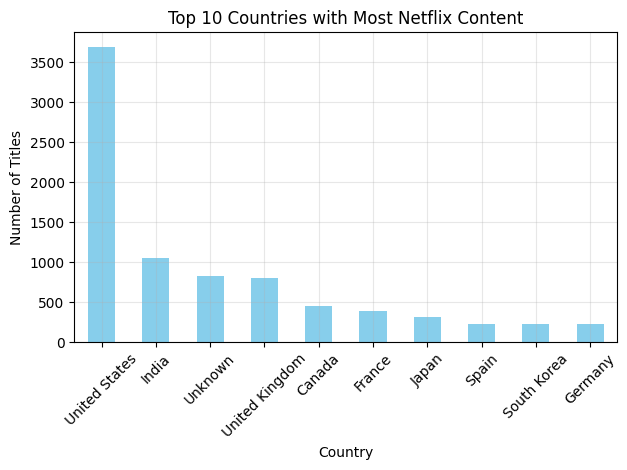

In [106]:
# Country distribution plot visualization
plt.Figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries with Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Content Type Distribution by Top Countries:
type            Movie  TV Show
country_single                
United States    2751      938
India             962       84
Unknown           440      391
United Kingdom    532      272
Canada            319      126
France            303       90
Japan             119      199
Spain             171       61
South Korea        61      170
Germany           182       44


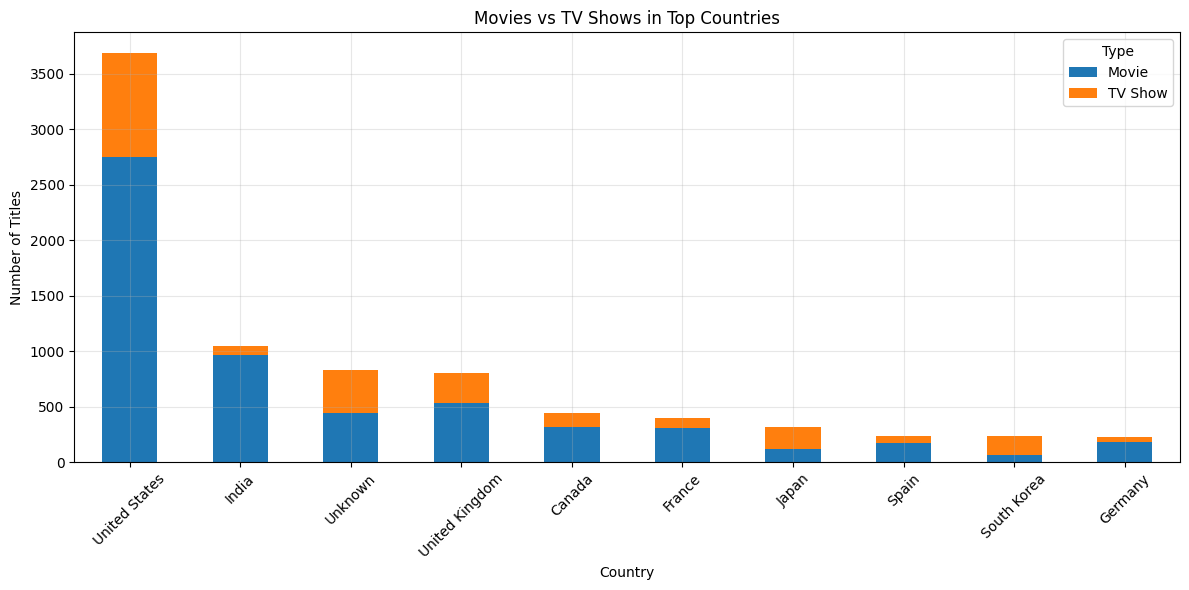

In [107]:
# Content type distribution by Top countries
country_type = df_expanded.groupby(['country_single', 'type']).size().unstack(fill_value=0)
country_type_top = country_type.loc[top_countries.index]
print("\nContent Type Distribution by Top Countries:")
print(country_type_top)

# Visualization
country_type_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Movies vs TV Shows in Top Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Taksk 2 - Similar Content by Text Features
* ### Combine text features

In [108]:
def combine_text_features(row):
    """Combined text features for content-based filtering."""
    features = []

    if row['director'] != 'Unknown':
        features.append(row['director'])
    if row['cast'] != 'Unknown':
        features.append(row['cast'])
    if row['listed_in'] != 'Unknown':
        features.append(row['listed_in'])
    if row['description'] != 'Unknown':
        features.append(row['description'])
    return ' '.join(features)

df['combined_features'] = df.apply(combine_text_features, axis=1)
print("Combined features for the first 5 rows:")
print(df[['title', 'combined_features']].head())

Combined features for the first 5 rows:
                   title                                  combined_features
0   Dick Johnson Is Dead  Kirsten Johnson Documentaries As her father ne...
1          Blood & Water  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2              Ganglands  Julien Leclercq Sami Bouajila, Tracy Gotoas, S...
3  Jailbirds New Orleans  Docuseries, Reality TV Feuds, flirtations and ...
4           Kota Factory  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...


In [109]:
# create TF-IDF Vectors
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8807, 5000)


In [110]:
# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Similarity Matrix Shape: {cosine_sim.shape}")

Similarity Matrix Shape: (8807, 8807)


## Find Similar Content

In [111]:
# Function to Find Similar Content
def find_similar_content(title, df, cosine_sim, n=5):
    """Find n similar content based on the title"""
    try:
        idx = df[df['title'] == title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores  = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:n+1]  # Exclude the first one
        similar_indices = [i[0] for i in sim_scores]
        similar_df = df.iloc[similar_indices][['title', 'type', 'director', 'cast']]
        similar_df['similarity_score'] = [score for _, score in sim_scores]
        return similar_df
    except IndexError:
        return f"Title '{title}' not found in the dataset."

# Apply the function to find similar 5 content for a given title
sample_title = df['title'].iloc[0]
print(f"Finding similar content for: {sample_title}")
find_similar_content(sample_title, df, cosine_sim, n=5)

Finding similar content for: Dick Johnson Is Dead


,title,type,director,cast,similarity_score
2350,Woodshock,Movie,"Kate Mulleavy, Laura Mulleavy","Kirsten Dunst, Joe Cole, Pilou Asbæk, Jack Kil...",0.235456
7015,How to Be a Player,Movie,Lionel C. Martin,"Bill Bellamy, Natalie Desselle, Lark Voorhies,...",0.207891
7454,Midnight Special,Movie,Jeff Nichols,"Michael Shannon, Joel Edgerton, Kirsten Dunst,...",0.175804
5233,The Death and Life of Marsha P. Johnson,Movie,David France,Unknown,0.175396
6553,Daffedar,Movie,Johnson Esthappan,"Tini Tom, Malavikka, Sudheer Karamana, Indrans",0.171306


In [112]:
# Test similarity on another title
test_title = df[df['type'] == 'TV Show']['title'].iloc[0]
print(f"\nContent similar to '{test_title}':")
find_similar_content(test_title, df, cosine_sim)


Content similar to 'Blood & Water':


,title,type,director,cast,similarity_score
5388,46,TV Show,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",0.224491
1654,Before 30,TV Show,BB Sasore,"Damilola Adegbite, O.C. Ukeje, Beverly Naya, M...",0.196697
5038,Re:Mind,TV Show,Unknown,Keyakizaka46,0.187894
3684,Kakegurui,TV Show,Unknown,"Minami Hamabe, Mahiro Takasugi, Aoi Morikawa",0.185200
5324,20 Minutes,TV Show,Unknown,"Tuba Büyüküstün, Ilker Aksum, Bülent Emin Yara...",0.181694


## Task 3 - Network Analysis

In [113]:
def create_network(df):
    """Create network graph connecting directors to actors"""
    G = nx.Graph()

    for _, row in df.iterrows():
        if row['director'] != 'Unknown' and row['cast'] != 'Unknown':
            director = row['director']
            actors = row['cast'].split(', ')

            if director not in G:
                G.add_node(director, type='director', content_count=1)
            else:
                G.nodes[director]['content_count'] += 1

            for actor in actors:
                if actor not in G:
                    G.add_node(actor, type='actor', content_count=1)
                else:
                    G.nodes[actor]['content_count'] += 1
                G.add_edge(director, actor)

    return G

G = create_network(df)
print("\nNetwork Statistics:")
print(f"Nodes (Directors + Actors): {G.number_of_nodes()}")
print(f"Edges (Collaborations): {G.number_of_edges()}")


Network Statistics:
Nodes (Directors + Actors): 30496
Edges (Collaborations): 43087


In [114]:
# Network Density and Connectivity
print(f"Network Density: {nx.density(G):.4f}")
print(f"Number of Connected Components: {nx.number_connected_components(G)}")

# Get largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(f"Largest Component Size: {len(largest_cc)} nodes")

Network Density: 0.0001
Number of Connected Components: 544
Largest Component Size: 27227 nodes



Top 10 Connected Directors:
Director                       | Centrality Score | Number of Movies/TV Shows
-----------------------------------------------------------------
Martin Scorsese                | 0.004            | 12
Steven Spielberg               | 0.004            | 12
Cathy Garcia-Molina            | 0.003            | 13
Don Michael Paul               | 0.003            | 11
Youssef Chahine                | 0.002            | 14
Kunle Afolayan                 | 0.002            | 11
Robert Rodriguez               | 0.002            | 8
Quentin Tarantino              | 0.002            | 9
McG                            | 0.002            | 7
Noah Baumbach                  | 0.002            | 6

Top 10 Connected Actors:
Actor                          | Centrality Score | Number of Movies/TV Shows
-----------------------------------------------------------------
Clint Eastwood                 | 0.002            | 12
Ron Howard                     | 0.002            | 8
An

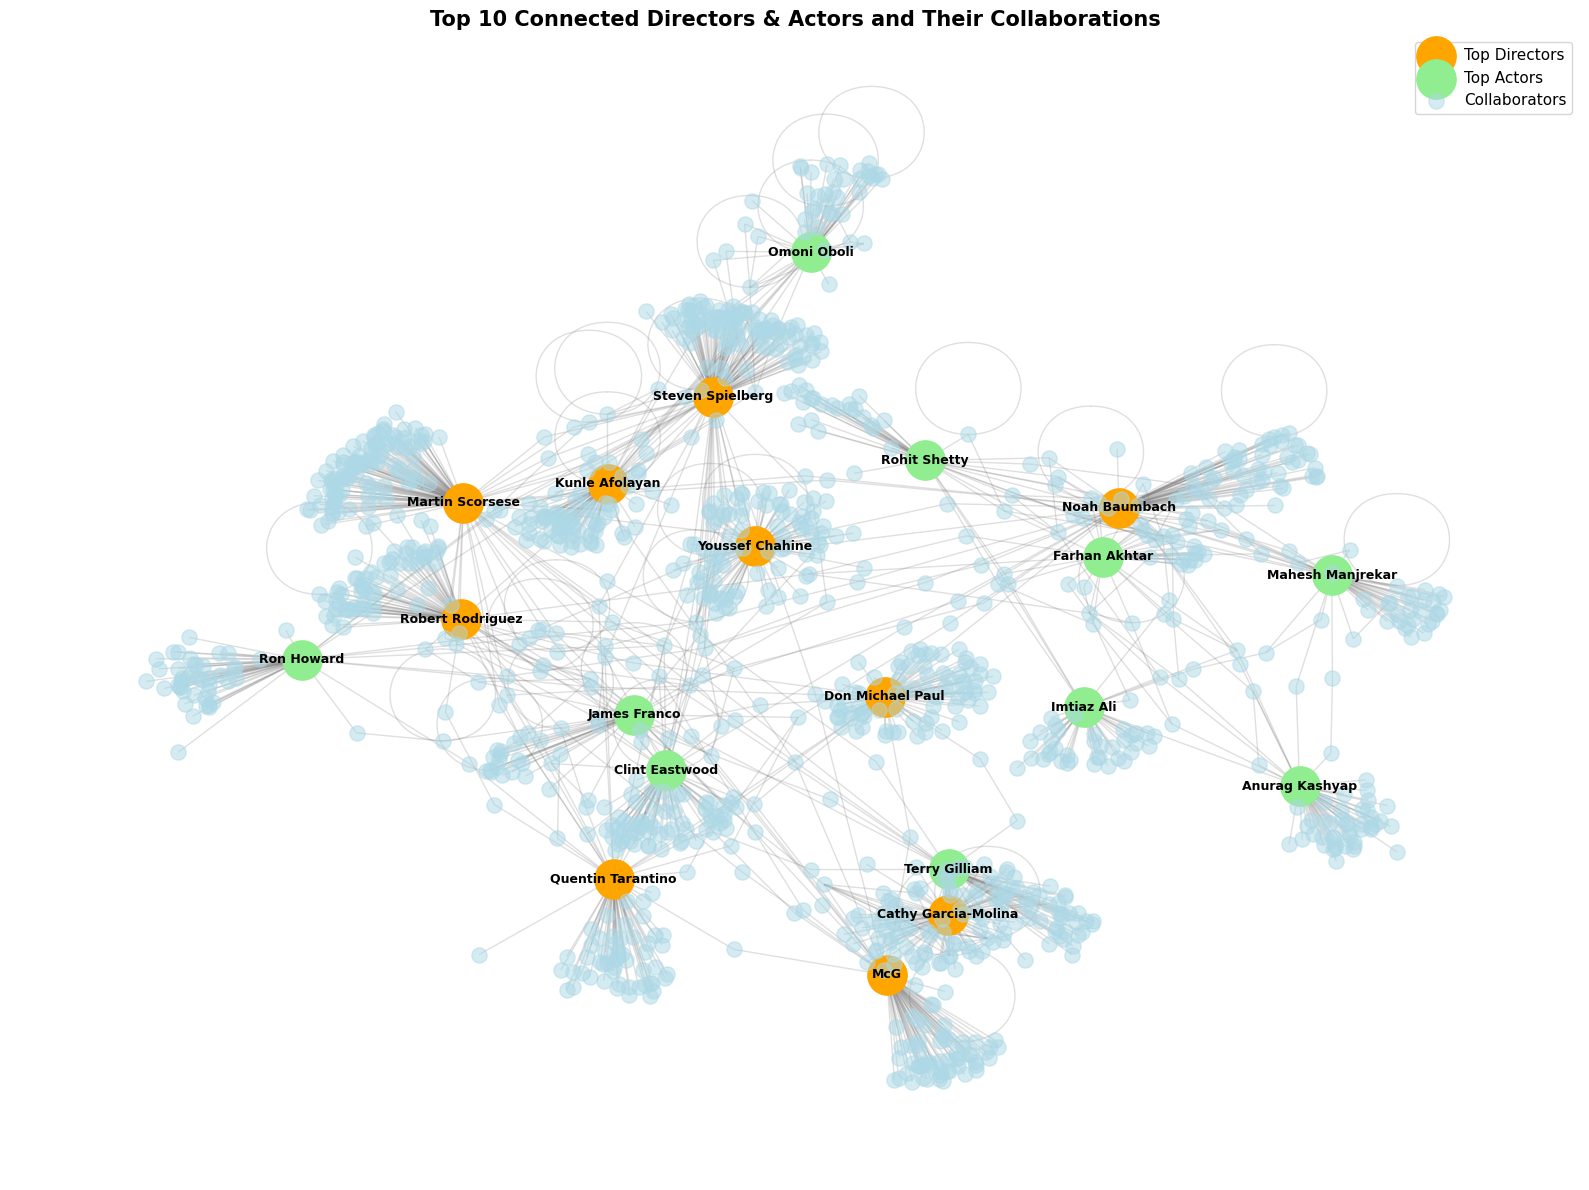

In [115]:
# 1. Compute Degree Centrality for Directors & Actors
degree_centrality = nx.degree_centrality(G)

directors = [
    (node, score, G.nodes[node].get('content_count', 0))
    for node, score in degree_centrality.items() 
    if G.nodes[node].get('type') == 'director'
]
directors_sorted = sorted(directors, key=lambda x: x[1], reverse=True)[:10]

actors = [
    (node, score, G.nodes[node].get('content_count', 0))
    for node, score in degree_centrality.items()
    if G.nodes[node].get('type') == 'actor'
]
actors_sorted = sorted(actors, key=lambda x: x[1], reverse=True)[:10]

# 2. Print Top 10 Directors and Actors
print("\nTop 10 Connected Directors:")
print(f"{'Director':<30} | {'Centrality Score':<16} | Number of Movies/TV Shows")
print("-" * 65)
for director, score, count in directors_sorted:
    print(f"{director[:30]:<30} | {score:<16.3f} | {count}")

print("\nTop 10 Connected Actors:")
print(f"{'Actor':<30} | {'Centrality Score':<16} | Number of Movies/TV Shows")
print("-" * 65)
for actor, score, count in actors_sorted:
    print(f"{actor[:30]:<30} | {score:<16.3f} | {count}")

# 3. Extract Top Names and Construct Subgraph
top_directors = [director for director, _, _ in directors_sorted]
top_actors = [actor for actor, _, _ in actors_sorted]

# Collect all direct neighbors for both top directors and top actors
key_people = list(set(top_directors + top_actors))
collaborator_nodes = [
    neighbor 
    for person in key_people 
    for neighbor in G.neighbors(person)
]

subgraph_nodes = list(set(key_people + collaborator_nodes))
subgraph = G.subgraph(subgraph_nodes)

# 4. Plot Visualizations
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(subgraph, k=0.25, seed=42)

# Categorize nodes for distinct styling
# Handle cases where someone might be both a top director and top actor
top_directors_set = set(top_directors)
top_actors_set = set(top_actors) - top_directors_set 
other_nodes = [node for node in subgraph.nodes() if node not in top_directors_set and node not in top_actors_set]

# Draw Nodes with unique colors
nx.draw_networkx_nodes(
    subgraph, pos, nodelist=list(top_directors_set), 
    node_size=800, node_color='orange', label='Top Directors'
)
nx.draw_networkx_nodes(
    subgraph, pos, nodelist=list(top_actors_set), 
    node_size=800, node_color='lightgreen', label='Top Actors'
)
nx.draw_networkx_nodes(
    subgraph, pos, nodelist=other_nodes, 
    node_size=120, node_color='lightblue', alpha=0.5, label='Collaborators'
)

# Draw Edges
nx.draw_networkx_edges(subgraph, pos, edge_color='gray', alpha=0.25)

# Label top directors and top actors to keep the visual readable
key_labels = {node: node for node in key_people if node in subgraph}
nx.draw_networkx_labels(subgraph, pos, labels=key_labels, font_size=9, font_weight='bold')

plt.title("Top 10 Connected Directors & Actors and Their Collaborations", fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()

In [117]:
# Community Detection
try:
    from networkx.algorithms.community import greedy_modularity_communities

    # Sample a subgraph if too large for community detection
    if G.number_of_nodes() > 1000:
        largest_cc_nodes = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc_nodes)
        print(f"Using subgraph with {G_sub.number_of_nodes()} nodes for community detection.")
    else:
        G_sub = G

    communities = greedy_modularity_communities(G_sub)
    print(f"\nNumber of Communities Detected: {len(communities)}")
    print("Top 5 Communities (by size):")
    for i, community in enumerate(sorted(communities, key=len, reverse=True)[:5]):
        print(f"Community {i+1}: Size = {len(community)} members)")
        members = list(community)[:5]  # Show only first 5 members for brevity
        print(f"Members: {', '.join(members)}\n")

except Exception as e:
    print(f"Community detection failed: {e}")

Using subgraph with 27227 nodes for community detection.

Number of Communities Detected: 175
Top 5 Communities (by size):
Community 1: Size = 4482 members)
Members: Hailey McCann, Dermot Crowley, Adrian Schiller, Camille Guaty, Jim Curley

Community 2: Size = 2677 members)
Members: Sunny Hinduja, Indrajit Nattoji, Jai Vyas, Shweta Mehendale, Shadab Kamal

Community 3: Size = 1253 members)
Members: Marcos Carnevale, Duban Prado, Martín Bacigalupo, Omar Chaparro, Susi Sánchez

Community 4: Size = 859 members)
Members: Tara Morice, Phyllida Lloyd, Jay Russell, Geno Segers, Anne-Marie Duff

Community 5: Size = 843 members)
Members: Peter Skagen, J. Anthony Brown, Doug Murray, Amber Stevens West, Vondie Curtis-Hall



## Task 4 - TV Shows vs Movies Trend

In [124]:
df_recent = df[df['release_year'] >= 2012].copy()

# Group by year and type
yearly_type = df_recent.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# Calculate percentages
yearly_type['total'] = yearly_type['Movie'] + yearly_type['TV Show']
yearly_type['tv_show_pct'] = (yearly_type['TV Show'] / yearly_type['total']) * 100
yearly_type['movie_pct'] = (yearly_type['Movie'] / yearly_type['total']) * 100

print("Yearly Distribution (2012-2021):")
print(yearly_type)

Yearly Distribution (2012-2021):
type          Movie  TV Show  total  tv_show_pct  movie_pct
release_year                                               
2012            173       64    237    27.004219  72.995781
2013            225       63    288    21.875000  78.125000
2014            264       88    352    25.000000  75.000000
2015            398      162    560    28.928571  71.071429
2016            658      244    902    27.050998  72.949002
2017            767      265   1032    25.678295  74.321705
2018            767      380   1147    33.129904  66.870096
2019            633      397   1030    38.543689  61.456311
2020            517      436    953    45.750262  54.249738
2021            277      315    592    53.209459  46.790541


## Visualization - Movies vs TV Shows Over Time

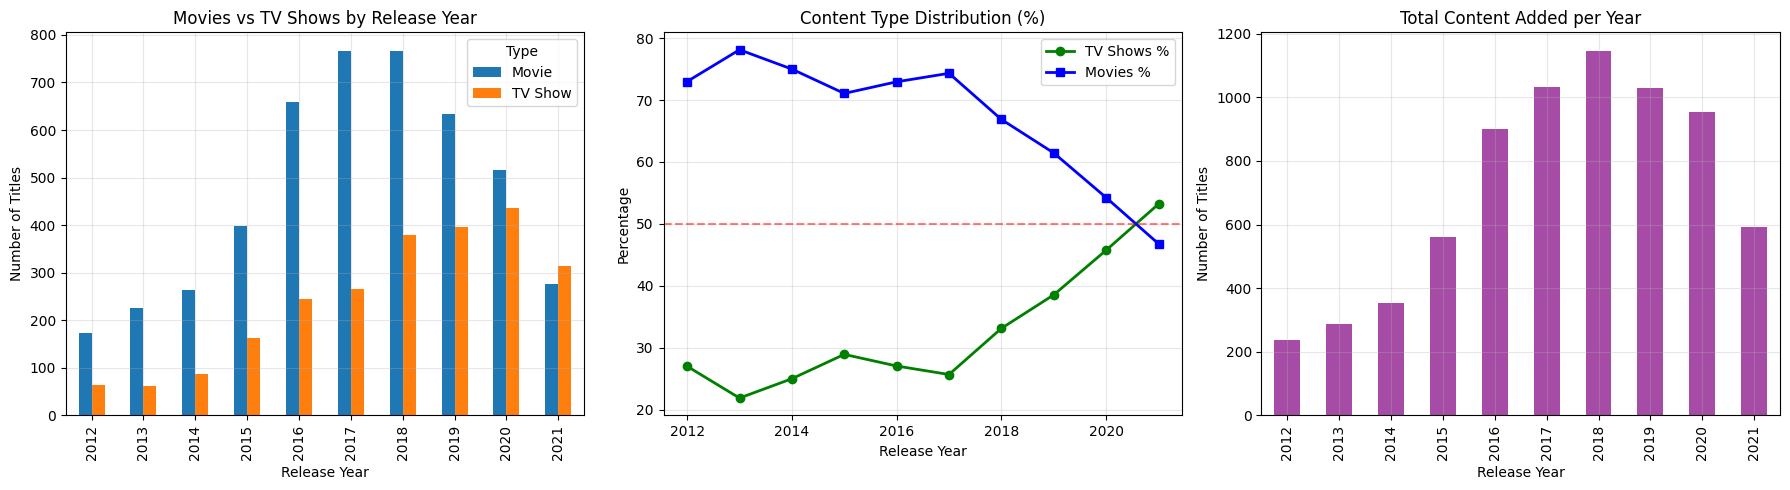

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Absolute counts
yearly_type[['Movie', 'TV Show']].plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Movies vs TV Shows by Release Year')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Number of Titles')
axes[0].legend(title='Type')
axes[0].grid(True, alpha=0.3)

# Plot 2: Percentage Trend
axes[1].plot(yearly_type.index, yearly_type['tv_show_pct'], marker='o', linewidth=2, 
             color='green', label='TV Shows %')
axes[1].plot(yearly_type.index, yearly_type['movie_pct'], marker='s', linewidth=2,
             color='blue', label='Movies %')
axes[1].set_title('Content Type Distribution (%)')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Percentage')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')

# Plot 3: Total Content Growth
yearly_type['total'].plot(kind='bar', ax=axes[2], color='purple', alpha=0.7)
axes[2].set_title('Total Content Added per Year')
axes[2].set_xlabel('Release Year')
axes[2].set_ylabel('Number of Titles')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Year-over-Year Growth Analysis

In [ ]:
yearly_type['movie_growth'] = yearly_type['Movie'].pct_change() * 100
yearly_type['tv_growth'] = yearly_type['TV Show'].pct_change() * 100
yearly_type['total_growth'] = yearly_type['total'].pct_change() * 100

print("Year-over-Year Growth Rates (%):")
print(yearly_type[['Movie', 'TV Show', 'movie_growth', 'tv_growth', 'total_growth']].round(2))

Year-over-Year Growth Rates (%):
type          Movie  TV Show  movie_growth  tv_growth  total_growth
release_year                                                       
2012            173       64           NaN        NaN           NaN
2013            225       63         30.06      -1.56         21.52
2014            264       88         17.33      39.68         22.22
2015            398      162         50.76      84.09         59.09
2016            658      244         65.33      50.62         61.07
2017            767      265         16.57       8.61         14.41
2018            767      380          0.00      43.40         11.14
2019            633      397        -17.47       4.47        -10.20
2020            517      436        -18.33       9.82         -7.48
2021            277      315        -46.42     -27.75        -37.88


In [127]:
# Cell 23: Monthly Trend Analysis
monthly_type = df[df['release_year'] >= 2015].groupby(['year_added', 'type']).size().unstack(fill_value=0)
monthly_type['tv_show_pct'] = (monthly_type['TV Show'] / (monthly_type['Movie'] + monthly_type['TV Show'])) * 100

print("Monthly TV Show Percentage Trend:")
print(monthly_type[['Movie', 'TV Show', 'tv_show_pct']].round(2).tail(12))

Monthly TV Show Percentage Trend:
type        Movie  TV Show  tv_show_pct
year_added                             
2013            0        1       100.00
2015           42       10        19.23
2016          191       91        32.27
2017          619      232        27.26
2018          785      357        31.26
2019          905      514        36.22
2020          875      530        37.72
2021          600      464        43.61


In [128]:
# Statistical test
from scipy import stats

# Compare TV Show percentages between 2012-2015 and 2016-2021
early_years = yearly_type.loc[2012:2015, 'tv_show_pct']
late_years = yearly_type.loc[2016:2021, 'tv_show_pct']

t_stat, p_value = stats.ttest_ind(early_years, late_years)
print(f"T-test Comparing TV Show Percentages (2012-2015 vs 2016-2021):")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant increase in TV Shows over time (p < 0.05)")
else:
    print("❌ No significant change in TV Shows proportion")

T-test Comparing TV Show Percentages (2012-2015 vs 2016-2021):
T-statistic: -2.043
P-value: 0.0753
❌ No significant change in TV Shows proportion


## Final Summary and Conclusions

In [129]:
print("="*60)
print("NETFLIX CONTENT ANALYSIS - SUMMARY")
print("="*60)

print("\n1. CONTENT BY COUNTRY:")
print(f" - Top Country: {top_countries.index[0]} ({top_countries.iloc[0]} titles)")
print(f"   - Top 5 countries contribute {top_countries.iloc[:5].sum()} titles")

print("\n2. SIMILAR CONTENT:")
print(f"   - TF-IDF matrix size: {tfidf_matrix.shape}")
print(f"   - Content similarity works by combining director, cast, genre, and description")

print("\n3. NETWORK ANALYSIS:")
print(f"   - Network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"   - Most connected director: {directors_sorted[0][0]} (score: {directors_sorted[0][1]:.3f})")
print(f"   - Most connected actor: {actors_sorted[0][0]} (score: {actors_sorted[0][1]:.3f})")
print(f"   - Found {len(communities) if 'communities' in locals() else 'N/A'} communities")

print("\n4. TV SHOWS vs MOVIES TREND:")
print(f"   - TV Show percentage 2015: {yearly_type.loc[2015, 'tv_show_pct']:.1f}%")
print(f"   - TV Show percentage 2021: {yearly_type.loc[2021, 'tv_show_pct']:.1f}%")
print(f"   - Change: {yearly_type.loc[2021, 'tv_show_pct'] - yearly_type.loc[2015, 'tv_show_pct']:.1f}%")

if yearly_type.loc[2021, 'tv_show_pct'] > yearly_type.loc[2015, 'tv_show_pct']:
    print("\n✅ CONCLUSION: Netflix has increased focus on TV Shows compared to Movies.")
    print(f"   TV Shows grew from {yearly_type.loc[2015, 'tv_show_pct']:.1f}% to {yearly_type.loc[2021, 'tv_show_pct']:.1f}% of total content.")
else:
    print("\n❌ CONCLUSION: Netflix has NOT increased focus on TV Shows compared to Movies.")

print("\n" + "="*60)

NETFLIX CONTENT ANALYSIS - SUMMARY

1. CONTENT BY COUNTRY:
 - Top Country: United States (3689 titles)
   - Top 5 countries contribute 6815 titles

2. SIMILAR CONTENT:
   - TF-IDF matrix size: (8807, 5000)
   - Content similarity works by combining director, cast, genre, and description

3. NETWORK ANALYSIS:
   - Network has 30496 nodes and 43087 edges
   - Most connected director: Martin Scorsese (score: 0.004)
   - Most connected actor: Clint Eastwood (score: 0.002)
   - Found 175 communities

4. TV SHOWS vs MOVIES TREND:
   - TV Show percentage 2015: 28.9%
   - TV Show percentage 2021: 53.2%
   - Change: 24.3%

✅ CONCLUSION: Netflix has increased focus on TV Shows compared to Movies.
   TV Shows grew from 28.9% to 53.2% of total content.

